In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("supermarketAnalysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [5]:
df.shape

(1000, 17)

In [6]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [10]:
# total revenue of the supermarket

df['gross income'].sum()

15379.368999999999

In [11]:
# branch made the highest sales

df.groupby('Branch')['gross income'].sum()

Branch
Alex     5057.1605
Cairo    5057.0320
Giza     5265.1765
Name: gross income, dtype: float64

In [12]:
# city generated the most revenue

df.groupby('City')['gross income'].sum()

City
Mandalay     5057.0320
Naypyitaw    5265.1765
Yangon       5057.1605
Name: gross income, dtype: float64

In [13]:
# most popular payment method

df['Payment'].value_counts()

Ewallet        345
Cash           344
Credit card    311
Name: Payment, dtype: int64

In [14]:
# product line sold the most items

df.groupby('Product line')['Quantity'].sum()


Product line
Electronic accessories    971
Fashion accessories       902
Food and beverages        952
Health and beauty         854
Home and lifestyle        911
Sports and travel         920
Name: Quantity, dtype: int64

In [15]:
# branch has the highest average customer rating

df.groupby('Branch')['Rating'].mean()

Branch
Alex     7.027059
Cairo    6.818072
Giza     7.072866
Name: Rating, dtype: float64

In [16]:
# gender spends more money
df.groupby('Gender')['gross income'].sum()

Gender
Female    9270.0875
Male      6109.2815
Name: gross income, dtype: float64

In [17]:
# day has the highest sales

df['Day'] = df['Date'].dt.day_name()
df.groupby('Day')['gross income'].sum()

Day
Friday       2091.7305
Monday       1804.7180
Saturday     2672.4195
Sunday       2117.0425
Thursday     2159.4880
Tuesday      2451.5355
Wednesday    2082.4350
Name: gross income, dtype: float64

In [18]:
# product line gives highest profit
df.groupby('Product line')['gross income'].sum()

Product line
Electronic accessories    2587.5015
Fashion accessories       2585.9950
Food and beverages        2673.5640
Health and beauty         2342.5590
Home and lifestyle        2564.8530
Sports and travel         2624.8965
Name: gross income, dtype: float64

In [19]:
# customer type spends more
df.groupby('Customer type')['gross income'].sum()

Customer type
Member    9033.084
Normal    6346.285
Name: gross income, dtype: float64

In [20]:
# busiest shopping hour

df['Time'] = pd.to_datetime(df['Time'])

df['Hour'] = df['Time'].dt.hour

df.groupby('Hour')['Invoice ID'].count()

Hour
10    101
11     90
12     89
13    103
14     83
15    102
16     77
17     74
18     93
19    113
20     75
Name: Invoice ID, dtype: int64

In [21]:
# branch sells the most quantity

df.groupby('Branch')['Quantity'].sum() 

Branch
Alex     1859
Cairo    1820
Giza     1831
Name: Quantity, dtype: int64

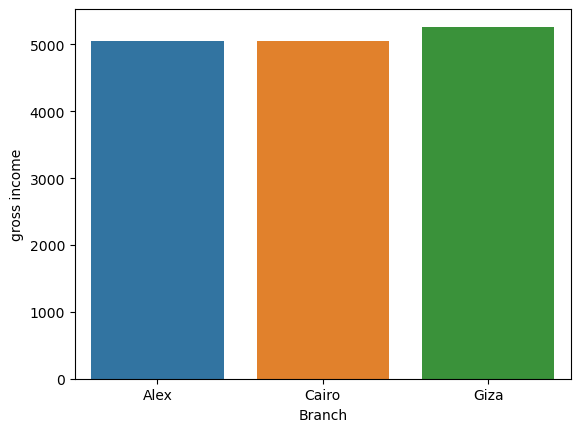

In [22]:
# bar chart of sales by branch

branch_sales = df.groupby('Branch')['gross income'].sum().reset_index()

sns.barplot(
    x='Branch',
    y='gross income',
    data=branch_sales
)

plt.show()

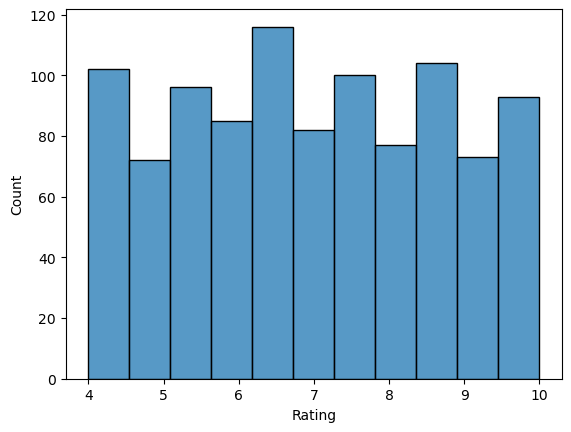

In [23]:
# histogram of customer ratings

sns.histplot(df['Rating'])

plt.show()

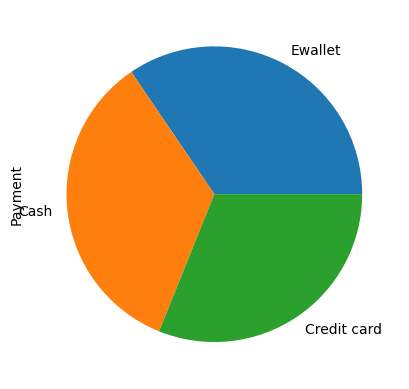

In [24]:
# pie chart for payment methods

df['Payment'].value_counts().plot(kind='pie')

plt.show()

In [25]:
df.groupby('Branch')['gross income'].sum()

Branch
Alex     5057.1605
Cairo    5057.0320
Giza     5265.1765
Name: gross income, dtype: float64

In [26]:
df['City'].unique()

array(['Yangon', 'Naypyitaw', 'Mandalay'], dtype=object)

In [27]:
# calculates average sales for each city.

average_sales_city = df.groupby('City')['gross income'].mean().reset_index()

print(average_sales_city)

        City  gross income
0   Mandalay     15.232024
1  Naypyitaw     16.052367
2     Yangon     14.874001


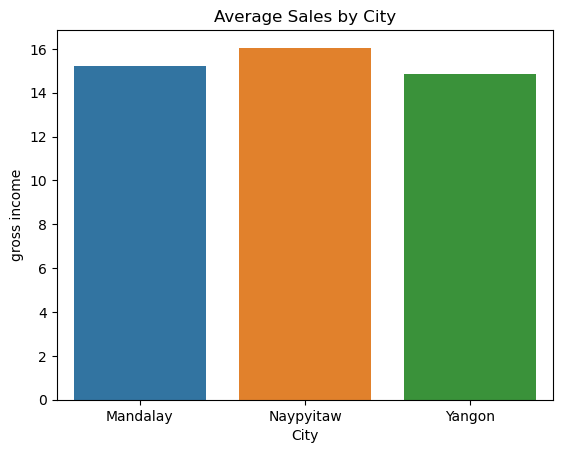

In [28]:
# Visualization

sns.barplot(
    x='City',
    y='gross income',
    data=average_sales_city
)

plt.title("Average Sales by City")

plt.show()

In [ ]:
# Insight:
Naypyitaw had the highest average sales among all cities.


In [37]:
highest_rated_product = df.groupby('Product line')['Rating'].mean()

print(highest_rated_product)

Product line
Electronic accessories    6.924706
Fashion accessories       7.029213
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        6.837500
Sports and travel         6.916265
Name: Rating, dtype: float64


In [38]:
highest_product = df.groupby('Product line')['Rating'].mean().idxmax()

print("Highest Rated Product Line:", highest_product)

Highest Rated Product Line: Food and beverages


In [29]:
# Find Branch with Highest Quantity Sold

branch_quantity = df.groupby('Branch')['Quantity'].sum()

print(branch_quantity)

Branch
Alex     1859
Cairo    1820
Giza     1831
Name: Quantity, dtype: int64


In [30]:
# To Find ONLY the Highest Branch

best_branch_quantity = df.groupby('Branch')['Quantity'].sum().idxmax()

print("Branch with Highest Quantity Sold:", best_branch_quantity)

Branch with Highest Quantity Sold: Alex


In [31]:
# Find Most Common Customer Type

customer_type_count = df['Customer type'].value_counts()

print(customer_type_count)

Member    565
Normal    435
Name: Customer type, dtype: int64


In [32]:
#  Find ONLY Most Common Customer Type

most_common_customer = df['Customer type'].mode()[0]

print("Most Common Customer Type:", most_common_customer)

Most Common Customer Type: Member


In [33]:
# Find Average Gross Income

average_gross_income = df['gross income'].mean()

print("Average Gross Income:", average_gross_income)

Average Gross Income: 15.379368999999999


In [39]:
summary_table = pd.DataFrame({
    'Highest Rated Product Line': [highest_product],
    'Branch with Highest Quantity Sold': [best_branch_quantity],
    'Most Common Customer Type': [most_common_customer],
    'Average Gross Income': [average_gross_income]
})

print(summary_table)

  Highest Rated Product Line Branch with Highest Quantity Sold  \
0         Food and beverages                              Alex   

  Most Common Customer Type  Average Gross Income  
0                    Member             15.379369  


In [ ]:
Insights:
- Branch C generated the highest revenue.
- E-wallet was the most preferred payment method.
- Food and beverages had the highest quantity sold.
- Member customers were more common than normal customers.